In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import torchvision.transforms as transforms
from sklearn.preprocessing import StandardScaler



In [32]:
test_data=pd.read_csv("data/labelled_test.csv")
train_data=pd.read_csv("data/labelled_train.csv")
validation_data=pd.read_csv("data/labelled_validation.csv")


In [34]:
test_data.tail()
test_data.head()

train_df = pd.read_csv('data/labelled_train.csv')
test_df = pd.read_csv('data/labelled_test.csv')
val_df = pd.read_csv('data/labelled_validation.csv')

# Separate features and labels for training, testing, and validation sets
X_train = train_df.drop('sus_label', axis=1).values
y_train = train_df['sus_label'].values
X_test = test_df.drop('sus_label', axis=1).values
y_test = test_df['sus_label'].values
X_val = val_df.drop('sus_label', axis=1).values
y_val = val_df['sus_label'].values

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train = scaler.fit_transform(X_train)

# Transform the test and validation data using the fitted scaler
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Convert the numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_ = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)



In [35]:
#budowa modelu
class Model(nn.Module):
    def __init__(self,input_features=7,h1=64,h2=32,h3=16,out=1):
        super().__init__()
        self.fc1=nn.Linear(input_features,h1)
        self.fc2=nn.Linear(h1,h2)
        self.fc3=nn.Linear(h2,h3)
        self.out=nn.Linear(h3,out)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        x = self.sigmoid(self.out(x))
        
        return x
    



In [42]:


#inicjalizacje i kopnwersja w tensory
model=Model()

X_train=torch.FloatTensor(X_train)
y_train=torch.FloatTensor(y_train)


X_test=torch.FloatTensor(X_test)
y_test=torch.FloatTensor(y_test)


X_val=torch.FloatTensor(X_val)
y_val=torch.FloatTensor(y_val)

#wybór parametrów


#criterion BCEW jest spoko dla 2 klas
#criterion = nn.BCEWithLogitsLoss()

criterion = nn.BCELoss()

optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [43]:
#datalaoder

dataset=TensorDataset(X_train,y_train)
dataloader=DataLoader(dataset, batch_size=64,shuffle=True)



In [ ]:
#training loop


epochs=10
losses=[]
accuracies=[]


for epoch in range(epochs):
    model.train()

    epoch_loss = 0

    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        y_pred=model.forward(X_batch)

        loss=criterion(y_pred,y_batch)


        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    losses.append(epoch_loss / len(dataloader))

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)
        preds = (torch.sigmoid(y_val_pred) > 0.5).float()
        acc = (preds == y_val).float().mean()
    print(f"Epoch {epoch:>3} | Train loss: {epoch_loss/len(dataloader):.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f}")
    accuracies.append(acc / len(dataloader))



Epoch   0 | Train loss: 0.0050 | Val loss: 0.0004 | Acc: 0.4906
Epoch   1 | Train loss: 0.0019 | Val loss: 0.0007 | Acc: 0.9718
Epoch   2 | Train loss: 0.0018 | Val loss: 0.0005 | Acc: 0.9559
Epoch   3 | Train loss: 0.0017 | Val loss: 0.0005 | Acc: 0.9460
Epoch   4 | Train loss: 0.0016 | Val loss: 0.0007 | Acc: 0.9856
Epoch   5 | Train loss: 0.0015 | Val loss: 0.0007 | Acc: 0.9743
Epoch   6 | Train loss: 0.0014 | Val loss: 0.0008 | Acc: 0.9884
Epoch   7 | Train loss: 0.0014 | Val loss: 0.0007 | Acc: 0.9753
Epoch   8 | Train loss: 0.0013 | Val loss: 0.0007 | Acc: 0.9761
Epoch   9 | Train loss: 0.0013 | Val loss: 0.0007 | Acc: 0.9621


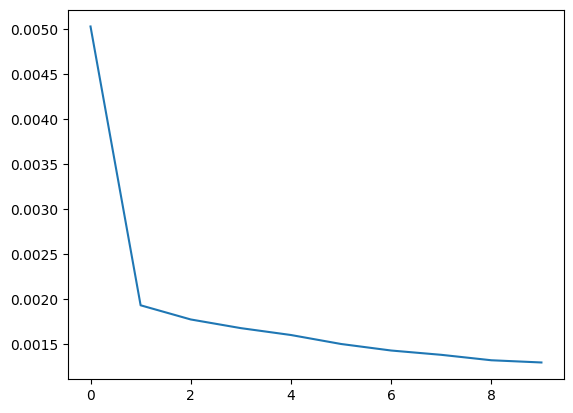

In [ ]:
plt.plot(range(epochs),losses)
plt.plot(range(epochs),accuracies)
plt.show()

In [ ]:

#test loop


with torch.no_grad():
    raw_out = model(X_test)
    predictions = (torch.sigmoid(raw_out).squeeze() > 0.5).float()



correct = (predictions.view(-1) == y_test.view(-1)).sum().item()
total = y_test.size(0)
accuracy = correct / total

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")






Final Test Accuracy: 95.30%
